# Descriptive Analysis

This descriptive analysis explores a dataset related to diabetes and associated health factors.
The dataset contains **253,680 observations and 22 features**, including key health indicators such as:

* Blood pressure (`HighBP`)
* Cholesterol (`HighChol`)
* Body Mass Index (`BMI`)
* Smoking habits (`Smoker`)
* Physical activity (`PhysActivity`)

It also includes demographic information such as **age, sex, education, and income**, as well as self-reported health indicators including **general health (`GenHlth`), mental health (`MentHlth`), and physical health (`PhysHlth`)**.

The objective of this analysis is to provide an overview of the dataset by examining:

* the structure and quality of the data
* the distribution of key variables
* potential patterns related to diabetes prevalence.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Initial Observations and Main Covered Areas

The first step is to inspect the dataset structure, including variable types and dataset dimensions.

All variables in this dataset are encoded as **numerical values (`float64`)**, meaning that categorical variables such as education, income, or sex are numerically encoded.

From an initial exploration, the dataset can be grouped into four main categories:

* **Diabetes status** (target variable)
* **Health indicators**
* **Demographic characteristics**
* **Lifestyle habits**

In [20]:
df = pd.read_csv("/Users/louisbarthelemy/Library/Mobile Documents/com~apple~CloudDocs/Mines Paris/3A/cookiecutter-data-science/Diabetes_prediction/data/diabetes_012_health_indicators_BRFSS2015.csv")
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [21]:
# Dataset information
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 no

In [22]:
# Missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

Missing Values:
Series([], dtype: int64)

Statistical Summary:
        Diabetes_012         HighBP       HighChol      CholCheck  \
count  253680.000000  253680.000000  253680.000000  253680.000000   
mean        0.296921       0.429001       0.424121       0.962670   
std         0.698160       0.494934       0.494210       0.189571   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       1.000000   
50%         0.000000       0.000000       0.000000       1.000000   
75%         0.000000       1.000000       1.000000       1.000000   
max         2.000000       1.000000       1.000000       1.000000   

                 BMI         Smoker         Stroke  HeartDiseaseorAttack  \
count  253680.000000  253680.000000  253680.000000         253680.000000   
mean       28.382364       0.443169       0.040571              0.094186   
std         6.608694       0.496761       0.197294              0.292087   
min        

## Population Analysis

Key characteristics of the population include:

* Individuals aged **18 to 80+ years**
* Both **male and female respondents**
* The **largest age group** falls within the **50–59 range**
* Over **40% of respondents completed four years of college or more**
* Around **36% of respondents belong to the highest income category ($75,000+)**

Because the survey relies on **self-reported data**, several variables may be subject to bias, including:

* difficulty walking
* mental health
* physical health
* alcohol consumption
* financial ability to visit a doctor.

These variables may be affected by **recall bias, social desirability bias, and cultural reporting differences**.

In [23]:
# Total population
total_count = df.shape[0]

# Diabetes counts
diabetes_counts = df["Diabetes_012"].value_counts().sort_index()

print("\nTotal Count of Individuals:", total_count)
print("\nDiabetes Counts:", diabetes_counts)

# Percentages
diabetes_percentage = diabetes_counts[2] / total_count * 100
pre_diabetes_percentage = diabetes_counts[1] / total_count * 100
no_diabetes_percentage = diabetes_counts[0] / total_count * 100

print("\nPercentage of Individuals with Diabetes:", diabetes_percentage)
print("\nPercentage of Individuals with Pre-Diabetes:", pre_diabetes_percentage)
print("\nPercentage of Individuals without Diabetes:", no_diabetes_percentage)


Total Count of Individuals: 253680

Diabetes Counts: Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64

Percentage of Individuals with Diabetes: 13.933301797540206

Percentage of Individuals with Pre-Diabetes: 1.8255282245348472

Percentage of Individuals without Diabetes: 84.24116997792494


Several key medical indicators are also examined to better understand the health profile of the population.

In [24]:
# High Blood Pressure
high_blood_pressure_counts = df["HighBP"].value_counts()
print("\nHigh Blood Pressure Counts:", high_blood_pressure_counts)

high_blood_pressure_percentage = high_blood_pressure_counts[1] / total_count * 100
print("\nPercentage of Individuals with High Blood Pressure:", high_blood_pressure_percentage)

# High Cholesterol
high_cholesterol_counts = df["HighChol"].value_counts()
print("\nHigh Cholesterol Counts:", high_cholesterol_counts)

high_cholesterol_percentage = high_cholesterol_counts[1] / total_count * 100
print("\nPercentage of Individuals with High Cholesterol:", high_cholesterol_percentage)

# Heart disease
heart_disease_counts = df["HeartDiseaseorAttack"].value_counts()
print("\nHeart Disease Counts:", heart_disease_counts)

heart_disease_percentage = heart_disease_counts[1] / total_count * 100
print("\nPercentage of Individuals with Heart Disease:", heart_disease_percentage)


High Blood Pressure Counts: HighBP
0.0    144851
1.0    108829
Name: count, dtype: int64

Percentage of Individuals with High Blood Pressure: 42.90011037527594

High Cholesterol Counts: HighChol
0.0    146089
1.0    107591
Name: count, dtype: int64

Percentage of Individuals with High Cholesterol: 42.41209397666351

Heart Disease Counts: HeartDiseaseorAttack
0.0    229787
1.0     23893
Name: count, dtype: int64

Percentage of Individuals with Heart Disease: 9.418558814254178


Lifestyle factors are also considered since they may influence diabetes risk, including smoking habits, physical activity, and alcohol consumption.

In [25]:
# Smokers
smokers_counts = df["Smoker"].value_counts()
print("\nSmokers Counts:", smokers_counts)

smokers_percentage = smokers_counts[1] / total_count * 100
print("\nPercentage of Smokers:", smokers_percentage)

# Physical activity
physical_activity_counts = df["PhysActivity"].value_counts()
print("\nPhysical Activity Counts:", physical_activity_counts)

physical_activity_percentage = physical_activity_counts[1] / total_count * 100
print("\nPercentage with Physical Activity:", physical_activity_percentage)

# Alcohol
alcohol_counts = df["HvyAlcoholConsump"].value_counts()
alcohol_percentage = alcohol_counts[1] / total_count * 100
print("\nPercentage consuming alcohol:", alcohol_percentage)


Smokers Counts: Smoker
0.0    141257
1.0    112423
Name: count, dtype: int64

Percentage of Smokers: 44.31685588142542

Physical Activity Counts: PhysActivity
1.0    191920
0.0     61760
Name: count, dtype: int64

Percentage with Physical Activity: 75.65436770734783

Percentage consuming alcohol: 5.619678334910123


## Descriptive Statistics and Distribution Analysis

The following visualizations illustrate the distributions of key demographic and health variables within the dataset.

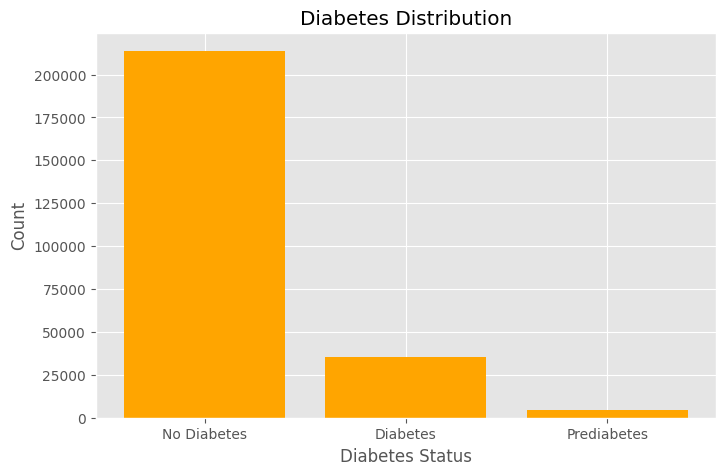

In [26]:
plt.style.use("ggplot")

diabetes_counts = df["Diabetes_012"].value_counts()
labels = ["No Diabetes", "Diabetes", "Prediabetes"]

plt.figure(figsize=(8,5))
plt.bar(labels, diabetes_counts, color='orange')
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.title("Diabetes Distribution")
plt.show()

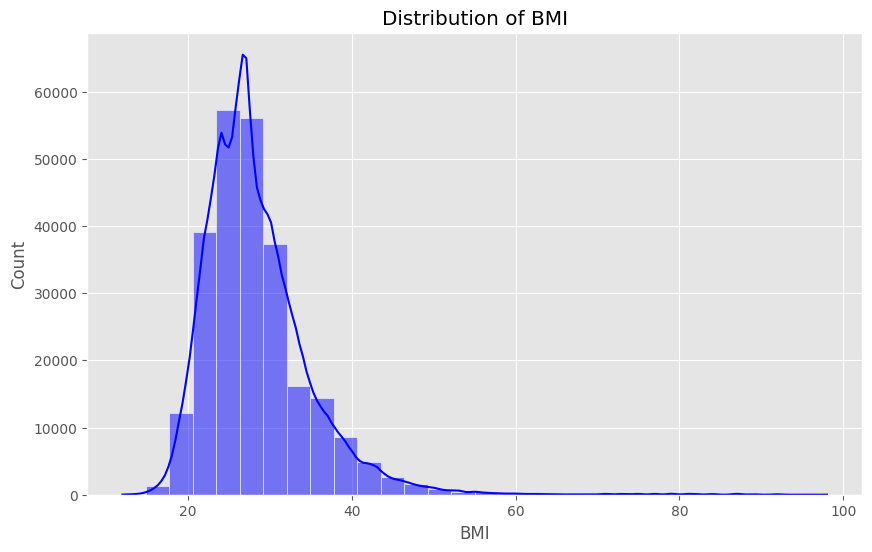

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df["BMI"], bins=30, kde=True, color='blue')
plt.title("Distribution of BMI")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

To improve interpretability, categorical demographic variables are converted from numeric codes into readable labels before visualization.

In [27]:
df

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0


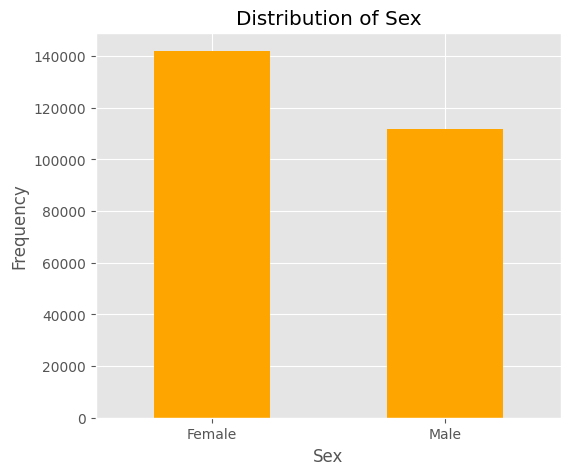

In [28]:
sex_mapping = {0: "Female", 1: "Male"}
df["Sex"] = df["Sex"].map(sex_mapping)

plt.figure(figsize=(6,5))
df["Sex"].value_counts().plot(kind='bar', color='orange')
plt.xlabel("Sex")
plt.ylabel("Frequency")
plt.title("Distribution of Sex")
plt.xticks(rotation=0)
plt.show()

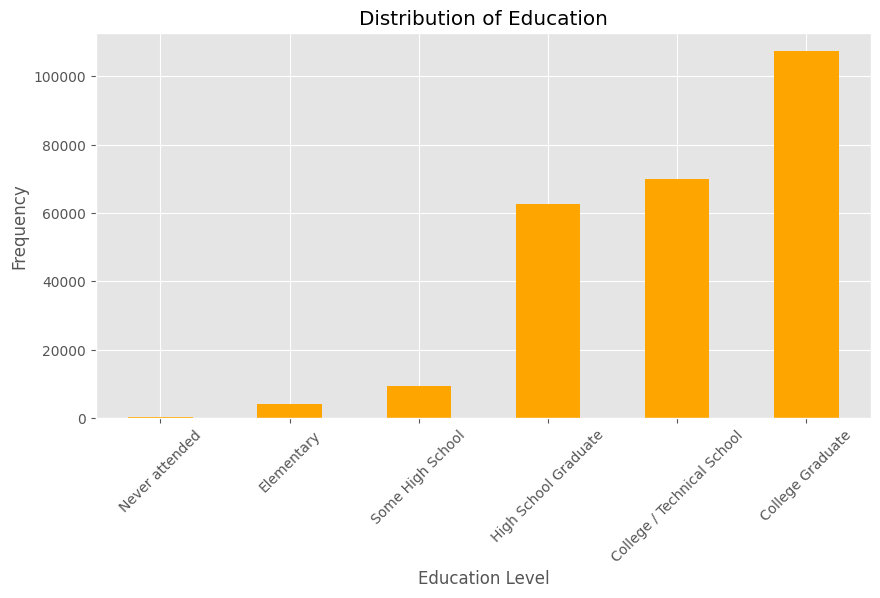

In [29]:
education_mapping = {
    1: "Never attended",
    2: "Elementary",
    3: "Some High School",
    4: "High School Graduate",
    5: "College / Technical School",
    6: "College Graduate"
}

df["Education"] = df["Education"].map(education_mapping)

plt.figure(figsize=(10,5))
df["Education"].value_counts().reindex(education_mapping.values(), fill_value=0).plot(kind='bar', color='orange')
plt.xlabel("Education Level")
plt.ylabel("Frequency")
plt.title("Distribution of Education")
plt.xticks(rotation=45)
plt.show()

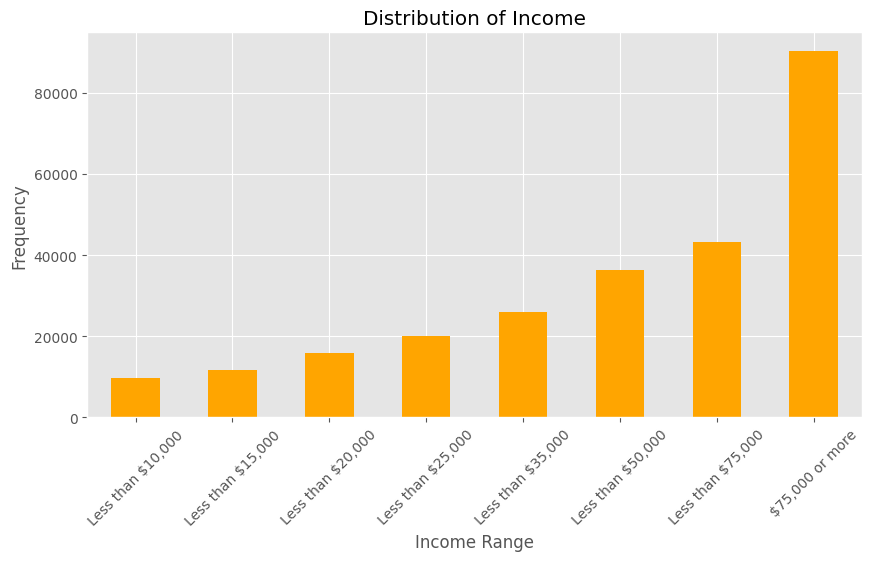

In [30]:
income_mapping = {
    1: "Less than $10,000",
    2: "Less than $15,000",
    3: "Less than $20,000",
    4: "Less than $25,000",
    5: "Less than $35,000",
    6: "Less than $50,000",
    7: "Less than $75,000",
    8: "$75,000 or more"
}

df["Income"] = df["Income"].map(income_mapping)

plt.figure(figsize=(10,5))
df["Income"].value_counts().reindex(income_mapping.values(), fill_value=0).plot(kind='bar', color='orange')
plt.xlabel("Income Range")
plt.ylabel("Frequency")
plt.title("Distribution of Income")
plt.xticks(rotation=45)
plt.show()

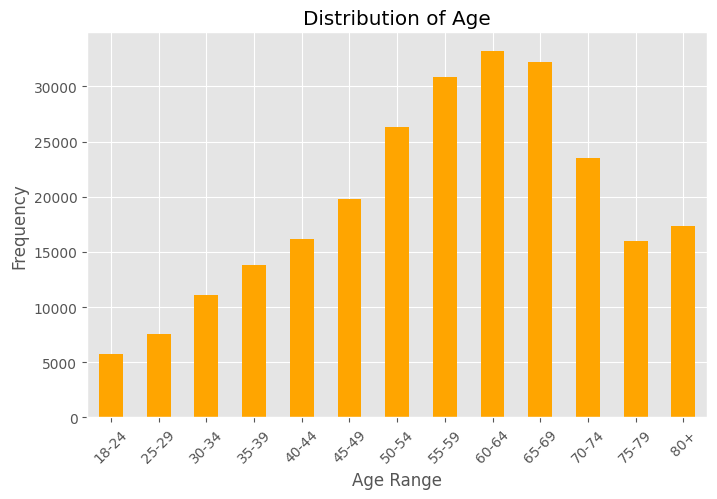

In [31]:
age_mapping = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39", 5: "40-44",
    6: "45-49", 7: "50-54", 8: "55-59", 9: "60-64", 10: "65-69",
    11: "70-74", 12: "75-79", 13: "80+"
}

df["Age"] = df["Age"].map(age_mapping)

plt.figure(figsize=(8,5))
df["Age"].value_counts().reindex(age_mapping.values(), fill_value=0).plot(kind='bar', color='orange')
plt.xlabel("Age Range")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.xticks(rotation=45)
plt.show()